In [48]:
import matplotlib.pyplot as plt
from src.TimeSeriesAnalysis import *
from IPython.display import clear_output
plt.style.use('properties.mplstyle')
from matplotlib.ticker import AutoMinorLocator, MultipleLocator
from matplotlib.lines import Line2D

In [5]:
savepath = "../results/TimeSeries"
create_folder(savepath)

Folder already exists: ../results/TimeSeries


In [6]:
# JOIN ALL DATA PROCESSING
type_perc = 'bond'
dim = 2

# 1) Ler convertendo "Null" para NaN
df_all_2d = pd.read_csv(
    f"../Data/{type_perc}_percolation/all_data_{dim}D.dat",
    sep="\t",
    na_values=["Null", "null", "NaN", "nan", ""]
)

# 2) (opcional) garantir numérico nas colunas de interesse
num_cols = ["rho","p0","order","num_samples","num_sample_perc",
            "pt_mean","pt_erro","nt_mean","nt_erro"]
for c in num_cols:
    if c in df_all_2d.columns:
        df_all_2d[c] = pd.to_numeric(df_all_2d[c], errors="coerce")

# 3) Filtrar linhas SEM NaN em pt_mean e nt_mean
df_clean_2d = df_all_2d.dropna(subset=["pt_mean","nt_mean"]).copy()

# ver somente um range de colunas
df_clean_2d.loc[:, "rho":"nt_erro"]

FileNotFoundError: [Errno 2] No such file or directory: '../Data/bond_percolation/all_data_2D.dat'

In [49]:
# JOIN ALL DATA PROCESSING
type_perc = 'bond'
dim = 3

# 1) Ler convertendo "Null" para NaN
df_all_3d = pd.read_csv(
    f"../Data/{type_perc}_percolation/all_data_{dim}D.dat",
    sep="\t",
    na_values=["Null", "null", "NaN", "nan", ""]
)

# 2) (opcional) garantir numérico nas colunas de interesse
num_cols = ["rho","p0","order","num_samples","num_sample_perc",
            "pt_mean","pt_erro","nt_mean","nt_erro"]
for c in num_cols:
    if c in df_all_3d.columns:
        df_all_3d[c] = pd.to_numeric(df_all_3d[c], errors="coerce")

# 3) Filtrar linhas SEM NaN em pt_mean e nt_mean
df_clean_3d = df_all_3d.dropna(subset=["pt_mean","nt_mean"]).copy()

# ver somente um range de colunas
df_clean_3d.loc[:, "rho":"nt_erro"]

,rho,p0,order,num_samples,num_sample_perc,pt_mean,pt_erro,nt_mean,nt_erro
0,0.00010,1.0,1,300,300,0.448912,0.002645,198.647164,0.398101
1,0.00010,1.0,2,300,300,0.449416,0.002626,198.790695,0.351748
2,0.00010,1.0,3,300,299,0.449224,0.002402,198.873092,0.321302
3,0.00010,1.0,4,300,288,0.442161,0.000561,199.939644,0.051675
4,0.00520,1.0,1,300,300,0.451733,0.002547,198.865652,0.358759
...,...,...,...,...,...,...,...,...,...
1159,0.22714,1.0,4,50,4,1.000000,0.000000,385.252145,54.745873
1160,0.22755,1.0,1,50,40,1.000000,0.000000,371.546242,29.409853
1161,0.22755,1.0,2,50,13,1.000000,0.000000,342.541335,33.376796
1162,0.22755,1.0,3,50,1,1.000000,0.000000,172.116396,0.000000


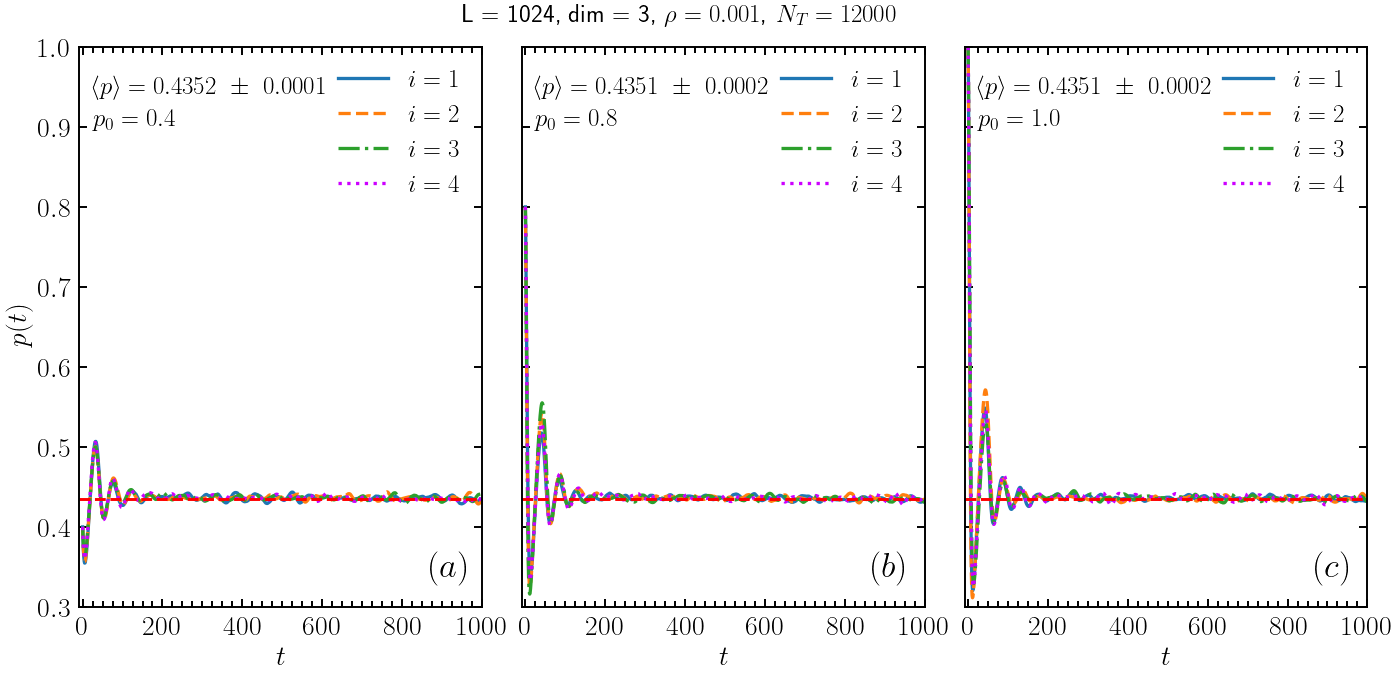

Resumo por subplot (média de p(t) na cauda + erro bootstrap entre as 4 curvas):
p0=0.4 | n_curves=4 | mean=0.435162 ± 0.000117 (IC95%: 0.434936–0.435388)
p0=0.8 | n_curves=4 | mean=0.435104 ± 0.000188 (IC95%: 0.434728–0.435480)
p0=1.0 | n_curves=4 | mean=0.435055 ± 0.000244 (IC95%: 0.434622–0.435599)


In [75]:
# ---------- seus parâmetros ----------
type_perc = "bond"
num_colors = 4
dim = 3
L = 1024
NT = 12000
k=1.0e-06
rho=1.0e-03
p0_lst = [0.4, 0.8, 1.0]
seed_name = [779543023, 1405683966, 712736555]

colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#cc00ff"]
fontsize_ticks = 20
font_labels = 20
thickness = 1.4

tail_frac = 0.30
n_boot    = 20000
ci        = 0.95

# ---------- plot + bootstrap ----------
fig, axes = plt.subplots(
    1, 3, sharey=True, figsize=(14,7),
    gridspec_kw={'wspace': 0.1, 'hspace': 0}  # pequeno respiro evita sobreposição do 0/400
)


results = []
rng = np.random.default_rng(12345)

count = 0
linestyles = ['solid', 'dashed', 'dashdot', "dotted", 'None']
labels_sub = ["$(a)$", "$(b)$", "$(c)$"]

major_step = 200   # 0, 100, 200, 300, 400
minor_step = 25    # subticks sem rótulo

for index, ax in enumerate(axes):
    p0 = p0_lst[index]
    data = data_single_sample(type_perc, num_colors, dim, L, NT, k, rho, p0, seed_name[index])
    
    for i in range(1, num_colors+1):
        ax.plot(data["t"], data[f"p_{i}"], ls=linestyles[i-1], label=f"$i = {i}$", linewidth=1.7*thickness, color=colors[i-1])

    ax.set_xlabel("$t$", fontsize=  font_labels)
    ax.set_xlim([0, max(data["t"])])
    ax.set_ylim([0.3, 1.0])

    means_per_curve = []
    for i in range(1, num_colors+1):
        mi = tail_mean(data[f"p_{i}"], tail_frac=tail_frac)
        if np.isfinite(mi):
            means_per_curve.append(mi)

    mean_pt, se_pt, (lo_pt, hi_pt) = bootstrap_mean_scalar(means_per_curve,prop='pt' ,n_boot=n_boot, ci=ci, rng=rng)
    results.append({"p0": p0, "mean": mean_pt, "se": se_pt, "lo": lo_pt, "hi": hi_pt, "n_used": len(means_per_curve)})
    count += mean_pt
    ax.legend(fontsize=18)
    #ax.set_title(fr"$p_0={p0:.1f}$", fontsize=18)
    txt1 = fmt_pm(mean_pt, se_pt, len(means_per_curve), dec=4)   # usa "<1e-3" se for minúsculo
    txt2 = rf"$p_0 = {p0:.1f}$"
    txt3 = ""
    ax.text(0.03, 0.95, txt1, transform=ax.transAxes, ha="left", va="top", fontsize=18)
    ax.text(0.03, 0.89, txt2, transform=ax.transAxes, ha="left", va="top", fontsize=18)
    ax.text(0.87, 0.1, labels_sub[index], transform=ax.transAxes, ha="left", va="top", fontsize=25)
    
    ax.xaxis.set_major_locator(MultipleLocator(major_step))
    ax.xaxis.set_minor_locator(MultipleLocator(minor_step))
    ax.tick_params(axis="both", which="major", labelsize=fontsize_ticks,
                   width=thickness, length=6, pad=6)
    ax.tick_params(axis="x", which="minor", width=thickness, length=4)

for ax in axes:
    ax.axhline(y=count/3, xmin=0, xmax=1.0, color='red', ls='--', lw=1.5*thickness)  # xmin/xmax em fração do eixo
    ax.set_xlim([-8, 1000])
axes[0].set_ylabel(r"$p(t)$", fontsize = font_labels)

# tira rótulos de y dos painéis internos para ficar limpo/colado
for ax in axes[1:]:
    ax.tick_params(labelleft=False)

# margens externas (não afetam o espaçamento entre subplots)
fig.suptitle(f"L = {L}, dim = {dim},  $\\rho = {rho}$, $N_T = {NT}$",
             fontsize=18, fontweight="bold", y=0.96)
fig.subplots_adjust(left=0.07, right=0.99, top=0.90, bottom=0.10)
plt.savefig(savepath + "/L_1024_pt_p0_effects.pdf", dpi=450)
plt.show()

# ---------- resumo no console ----------
print("Resumo por subplot (média de p(t) na cauda + erro bootstrap entre as 4 curvas):")
for r in results:
    print(f"p0={r['p0']:.1f} | n_curves={r['n_used']} | "
          f"mean={r['mean']:.6f} ± {r['se']:.6f} (IC{int(ci*100)}%: {r['lo']:.6f}–{r['hi']:.6f})")

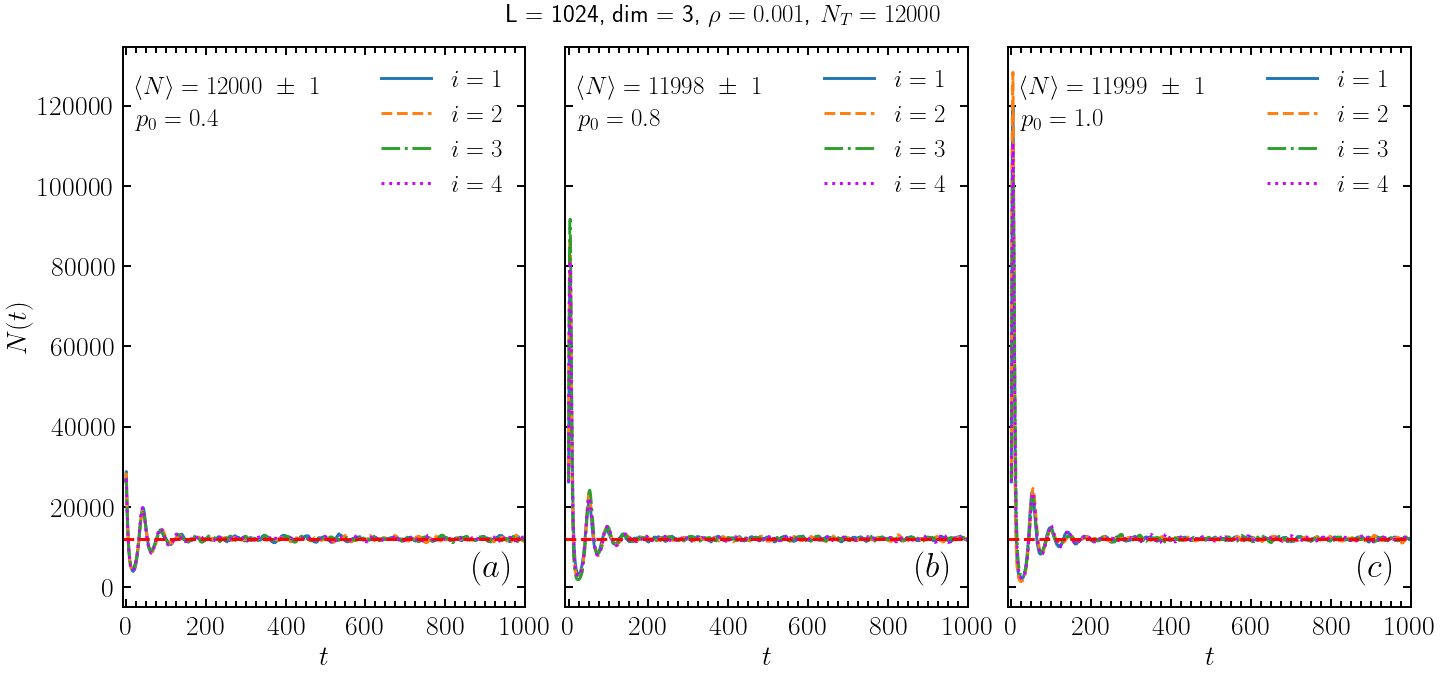

In [76]:
# ---------- seus parâmetros ----------
type_perc = "bond"
num_colors = 4
dim = 3
L = 1024
NT = 12000
k=1.0e-06
rho=1.0e-03
p0_lst = [0.4, 0.8, 1.0]
seed_name = [779543023, 1405683966, 712736555]


colors = ["#1f77b4", "#ff7f0e", "#2ca02c",  "#cc00ff"]
fontsize_ticks = 20
font_labels = 20

thickness = 1.4

tail_frac = 0.30
n_boot    = 20000
ci        = 0.95
labels_sub = ["$(a)$", "$(b)$", "$(c)$"]

# ---------- plot + bootstrap ----------
fig, axes = plt.subplots(
    1, 3, sharey=True, figsize=(14,7),
    gridspec_kw={'wspace': 0.1, 'hspace': 0}  # pequeno respiro evita sobreposição do 0/400
)

results = []
rng = np.random.default_rng(54321)

count = 0
linestyles = ['solid', 'dashed', 'dashdot', "dotted", 'None']
#linestyles = ['solid', 'solid', 'solid', 'solid']
for index, ax in enumerate(axes):
    p0 = p0_lst[index]
    data = data_single_sample(type_perc, num_colors, dim, L, NT, k, rho, p0, seed_name[index])
    
    for i in range(1, num_colors+1):
        ax.plot(data["t"], data[f"N_{i}"], ls=linestyles[i-1], label=f"$i = {i}$", linewidth=1.5*thickness, color=colors[i-1])

    ax.set_xlabel("$t$", fontsize=font_labels)
    ax.xaxis.set_major_locator(MultipleLocator(500))
    ax.set_xlim([0, max(data["t"])])
    #ax.set_ylim([0.4, 1.0])

    means_per_curve_Nt = []
    for i in range(1, num_colors+1):
        mi = tail_mean(data[f"N_{i}"], tail_frac=tail_frac)
        if np.isfinite(mi):
            means_per_curve_Nt.append(mi)

    mean_Nt, se_Nt, (lo_Nt, hi_Nt) = bootstrap_mean_scalar(means_per_curve_Nt, prop='Nt' ,n_boot=n_boot, ci=ci, rng=rng)
    results.append({"p0": p0, "mean": mean_Nt, "se": se_Nt, "lo": lo_Nt, "hi": hi_Nt, "n_used": len(means_per_curve_Nt)})
    count += mean_Nt
    ax.legend(fontsize=18)
    
    txt1 = fmt_pm_N(mean_Nt, se_Nt, n_used=len(means_per_curve_Nt), dec=0)  # ajuste dec se quiser
    txt2 = rf"$p_0 = {p0:.1f}$"
    ax.text(0.03, 0.95, txt1, transform=ax.transAxes, ha="left", va="top", fontsize=18)
    ax.text(0.03, 0.89, txt2, transform=ax.transAxes, ha="left", va="top", fontsize=18)
    ax.text(0.87, 0.1, labels_sub[index], transform=ax.transAxes, ha="left", va="top", fontsize=25)
    ax.xaxis.set_major_locator(MultipleLocator(major_step))
    ax.xaxis.set_minor_locator(MultipleLocator(minor_step))
    ax.tick_params(axis="both", which="major", labelsize=fontsize_ticks,
                   width=thickness, length=6, pad=6)
    ax.tick_params(axis="x", which="minor", width=thickness, length=4)

for ax in axes:
    ax.axhline(y=count/3, xmin=0, xmax=1.0, color='r', ls='--', lw=1.5*thickness)  # xmin/xmax em fração do eixo
    ax.set_xlim([-8, 1000])

axes[0].set_ylabel(r"$N(t)$", fontsize=font_labels)
# tira rótulos de y dos painéis internos para ficar limpo/colado
for ax in axes[1:]:
    ax.tick_params(labelleft=False)

# margens externas (não afetam o espaçamento entre subplots)
fig.suptitle(f"L = {L}, dim = {dim},  $\\rho = {rho}$, $N_T = {NT}$",
             fontsize=18, fontweight="bold", y=0.96)
fig.subplots_adjust(left=0.07, right=0.99, top=0.90, bottom=0.10)
plt.savefig(savepath + "/L_1024_Nt_p0_effects.pdf", dpi=450)
plt.show()

# # ---------- resumo no console ----------
# print("Resumo por subplot (média de p(t) na cauda + erro bootstrap entre as 4 curvas):")
# for r in results:
#     print(f"p0={r['p0']:.1f} | n_curves={r['n_used']} | "
#           f"mean={r['mean']:.6f} ± {r['se']:.6f} (IC{int(ci*100)}%: {r['lo']:.6f}–{r['hi']:.6f})")

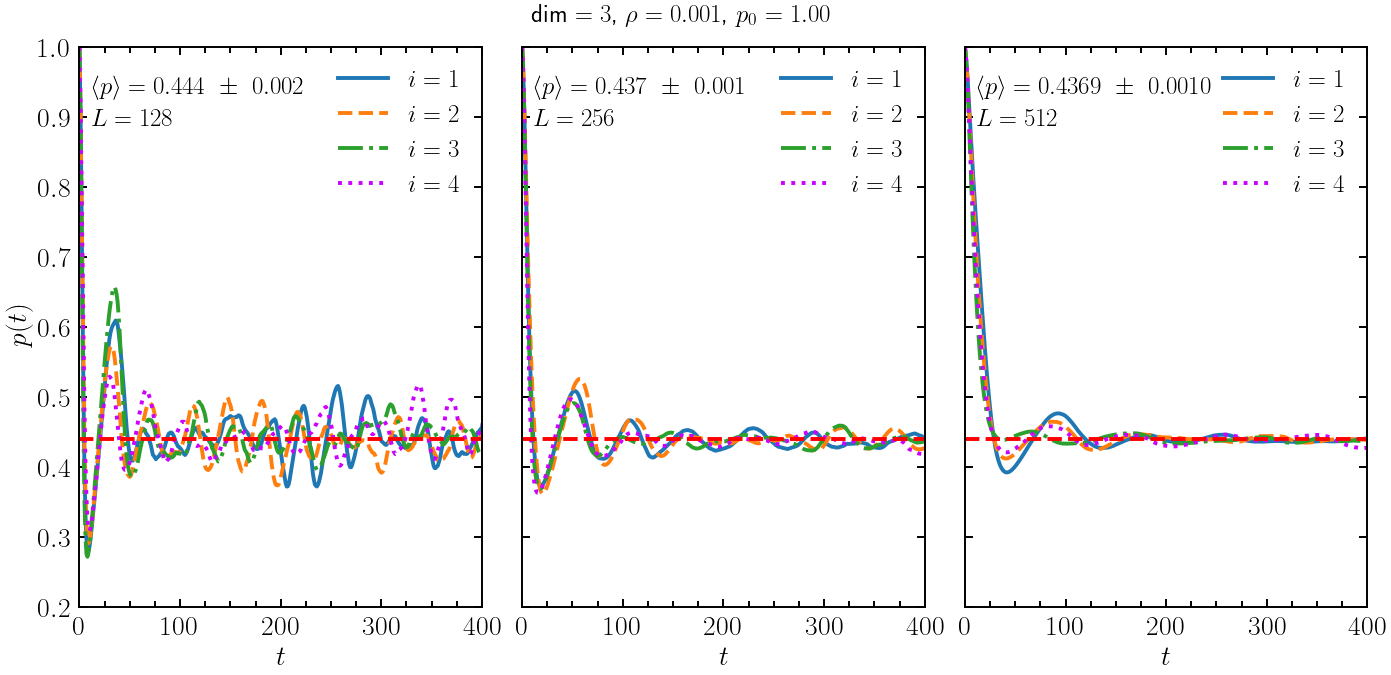

In [77]:
from matplotlib.ticker import MultipleLocator

# ---------- parâmetros (três tamanhos) ----------
type_perc = "bond"
num_colors = 4
dim = 3
L_list  = [128, 256, 512]
NT_list = [200, 800, 3500]
k_list  = [1.0e-04, 1.0e-05, 1.0e-06]
rho = 1.0e-03
p0  = 1.00
seed_list = [1884492735, 1352196575, 1903598064]

fontsize_ticks = 20
font_labels = 20
thickness = 1.4
tail_frac = 0.30
n_boot    = 20000
ci        = 0.95


# ---------- plot + bootstrap ----------
fig, axes = plt.subplots(
    1, 3, sharey=True, figsize=(14,7),
    gridspec_kw={'wspace': 0.1, 'hspace': 0}  # pequeno respiro evita sobreposição do 0/400
)

results = []
rng = np.random.default_rng(12345)
count = 0

# locators para ticks e subticks
major_step = 100   # 0, 100, 200, 300, 400
minor_step = 25    # subticks sem rótulo

for j, (ax, L, NT, kk, seed) in enumerate(zip(axes, L_list, NT_list, k_list, seed_list)):
    data = data_single_sample(type_perc, num_colors, dim, L, NT, kk, rho, p0, seed)

    # curvas p_i(t)
    linestyles = ['solid', 'dashed', 'dashdot', 'dotted']
    colors = ["#1f77b4", "#ff7f0e", "#2ca02c",  "#cc00ff"]
    for i in range(1, num_colors+1):
        ax.plot(data["t"], data[f"p_{i}"], ls=linestyles[i-1],
                label=f"$i = {i}$", linewidth=2*thickness, color=colors[i-1])

    # ----- eixo x local (0–400) com subticks -----
    ax.set_xlim([0, 400])
    ax.set_ylim(0.2, 1.0)
    ax.set_xlabel("$t$",fontsize=font_labels)

    ax.xaxis.set_major_locator(MultipleLocator(major_step))
    ax.xaxis.set_minor_locator(MultipleLocator(minor_step))

    # aparência dos ticks
    ax.tick_params(axis="both", which="major", labelsize=fontsize_ticks,
                   width=thickness, length=6, pad=6)
    ax.tick_params(axis="x", which="minor", width=thickness, length=4)

    # (opcional, para reforçar que é eixo local) legenda curta do intervalo:
    # ax.text(0.98, -0.16, r"[0, 400]", transform=ax.transAxes,
    #         ha="right", va="top", fontsize=fontsize_ticks-2)

    # ===== resto do seu código inalterado =====
    means_per_curve = [tail_mean(data[f"p_{i}"], tail_frac=tail_frac)
                       for i in range(1, num_colors+1)]
    means_per_curve = [m for m in means_per_curve if np.isfinite(m)]

    mean_pt, se_pt, (lo_pt, hi_pt) = bootstrap_mean_scalar(
        means_per_curve, prop='pt' ,n_boot=n_boot, ci=ci, rng=rng)
    results.append({"L": L, "NT": NT, "k": kk, "mean": mean_pt, "se": se_pt,
                    "lo": lo_pt, "hi": hi_pt, "n_used": len(means_per_curve)})

    ax.legend(fontsize=18)
    txt1 = fmt_pm(mean_pt, se_pt, n_used=len(means_per_curve),
                  dec=(3 if count!=2 else 4))
    txt2 = rf"$L = {L}$"
    ax.text(0.03, 0.95, txt1, transform=ax.transAxes, ha="left", va="top", fontsize=18)
    ax.text(0.03, 0.89, txt2, transform=ax.transAxes, ha="left", va="top", fontsize=18)
    count += 1

axes[0].set_ylabel(r"$p(t)$",fontsize=font_labels)
for ax in axes[1:]:
    ax.tick_params(labelleft=False)

# (opcional) remova as linhas verticais de "divisão" se estiver usando:
# for ax in axes: pass  # não desenhar axvline(400)

# linha média global
global_mean = np.nanmean([r["mean"] for r in results])
for ax in axes:
    ax.axhline(y=global_mean, xmin=0, xmax=1.0, color='red', ls='--', lw=2*thickness)

fig.suptitle(fr"dim $= {dim}$, $\rho={rho}$, $p_0={p0:.2f}$",
             fontsize=18, fontweight="bold", y=0.96)
fig.subplots_adjust(left=0.07, right=0.99, top=0.90, bottom=0.10)
plt.savefig(savepath + "/pt_p0_1.0_L_effects.pdf", dpi=450)
plt.show()


In [20]:
# JOIN ALL DATA PROCESSING
type_perc = 'bond'
dim = 3

# 1) Ler convertendo "Null" para NaN
df_all_3d = pd.read_csv(
    f"../Data/{type_perc}_percolation/all_data_{dim}D.dat",
    sep="\t",
    na_values=["Null", "null", "NaN", "nan", ""]
)

# 2) (opcional) garantir numérico nas colunas de interesse
num_cols = ["rho","p0","order","num_samples","num_sample_perc",
            "pt_mean","pt_erro","nt_mean","nt_erro"]
for c in num_cols:
    if c in df_all_3d.columns:
        df_all_3d[c] = pd.to_numeric(df_all_3d[c], errors="coerce")

# 3) Filtrar linhas SEM NaN em pt_mean e nt_mean
df_clean_3d = df_all_3d.dropna(subset=["pt_mean","nt_mean"]).copy()


# ver somente um range de colunas
df_clean_3d

# Filtrar simulações onde todos percolam

,type_perc,num_colors,dim,L,Nt,k,rho,p0,order,num_samples,num_sample_perc,pt_mean,pt_erro,nt_mean,nt_erro,M_size_mean,M_size_erro,perc_rate
0,bond,4,3,128,200,0.000100,0.00010,1.0,1,300,300,0.448912,0.002645,198.647164,0.398101,1.125517e+05,3472.908193,1.000000
1,bond,4,3,128,200,0.000100,0.00010,1.0,2,300,300,0.449416,0.002626,198.790695,0.351748,1.135431e+05,3428.903280,1.000000
2,bond,4,3,128,200,0.000100,0.00010,1.0,3,300,299,0.449224,0.002402,198.873092,0.321302,1.116118e+05,3173.154153,0.996667
3,bond,4,3,128,200,0.000100,0.00010,1.0,4,300,288,0.442161,0.000561,199.939644,0.051675,1.024593e+05,873.938650,0.960000
4,bond,4,3,128,200,0.000100,0.00520,1.0,1,300,300,0.451733,0.002547,198.865652,0.358759,1.116717e+05,3170.388510,1.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1159,bond,4,3,512,3500,0.000001,0.22714,1.0,4,50,4,1.000000,0.000000,385.252145,54.745873,1.079046e+06,301453.130504,0.080000
1160,bond,4,3,512,3500,0.000001,0.22755,1.0,1,50,40,1.000000,0.000000,371.546242,29.409853,2.081274e+06,170086.486203,0.800000
1161,bond,4,3,512,3500,0.000001,0.22755,1.0,2,50,13,1.000000,0.000000,342.541335,33.376796,1.939147e+06,201409.201902,0.260000
1162,bond,4,3,512,3500,0.000001,0.22755,1.0,3,50,1,1.000000,0.000000,172.116396,0.000000,1.343543e+06,0.000000,0.020000


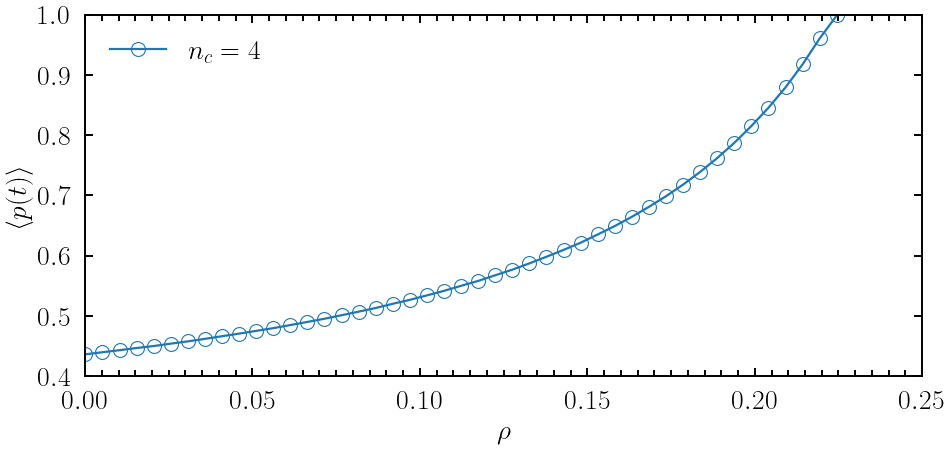

In [85]:
# --- selecione e limpe (igual ao seu) ---
df_plot = df_all4[(df_all4["L"] == 512) & (df_all4["order"] == 1)].copy()
for c in ["rho", "pt_mean", "pt_erro"]:
    if c in df_plot.columns:
        df_plot[c] = pd.to_numeric(df_plot[c], errors="coerce")
df_plot = df_plot.dropna(subset=["rho", "pt_mean"]).sort_values("rho")

# base para medir o passo: apenas rho <= 0.20
rho_base = df_plot.loc[df_plot["rho"] <= 0.20, "rho"].drop_duplicates().to_numpy()
rho_base.sort()
# passo típico (evita outliers)
dr = np.median(np.diff(rho_base))

# grade uniforme cobrindo TODO o domínio disponível
rmin = float(df_plot["rho"].min())
rmax = float(df_plot["rho"].max())
rho_uni = np.arange(rmin, rmax + 0.5*dr, dr)
rho_uni = rho_uni[rho_uni <= rmax]  # evita passar do último ponto

# interpolação na grade uniforme (usa todos os dados como referência)
x = df_plot["rho"].to_numpy()
y = df_plot["pt_mean"].to_numpy()
pt_uni = np.interp(rho_uni, x, y)


fontsize_ticks = 20
font_labels = 20
ms = 10

# --- plot "normal" com pontos igualmente espaçados ---
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(rho_uni, pt_uni, "o-", ms=ms, lw=1.6, label=r"$n_c = 4$")
ax.set_xlabel(r"$\rho$",fontsize=font_labels)
ax.set_ylabel(r"$\langle p(t) \rangle$", fontsize = font_labels)
ax.legend()
ax.set_xlim([0.0, 0.25])
ax.set_ylim(0.4, 1.0)

major_step_x = 0.05   # 0, 100, 200, 300, 400
minor_step_x = 0.005    # subticks sem rótulo
ax.xaxis.set_major_locator(MultipleLocator(major_step_x))
ax.xaxis.set_minor_locator(MultipleLocator(minor_step_x))

major_step_y = 0.1   # 0, 100, 200, 300, 400
ax.yaxis.set_major_locator(MultipleLocator(major_step_y))
# aparência dos ticks
ax.tick_params(axis="both", which="major", labelsize=fontsize_ticks,
                width=thickness, length=6, pad=10)
ax.tick_params(axis="x", which="minor", width=thickness, length=4)

plt.tight_layout()
#plt.yscale("log")
plt.savefig(savepath + "/p_mean_X_rho.pdf", dpi=300)
plt.show()


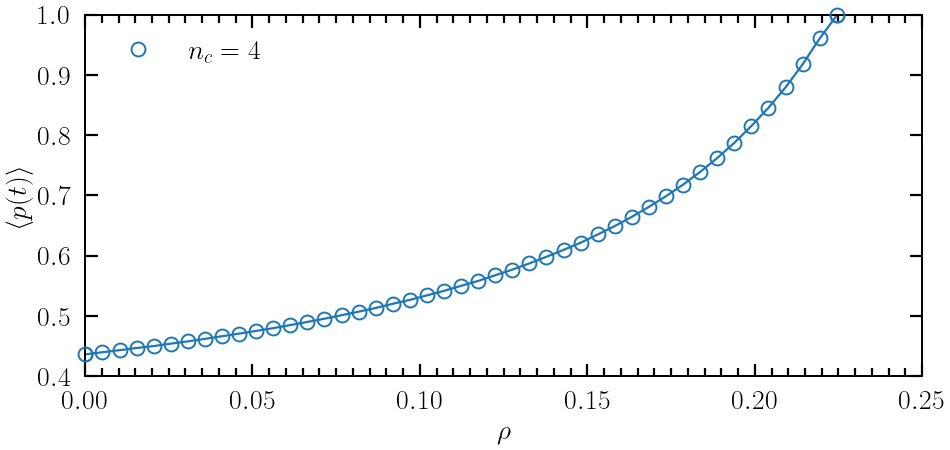

In [96]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
from matplotlib.lines import Line2D

# ================== 1) Seleção, limpeza e reamostragem uniforme ==================
# Supondo que df_all4 já exista no seu ambiente
df_plot = df_all4[(df_all4["L"] == 512) & (df_all4["order"] == 1)].copy()

for c in ["rho", "pt_mean", "pt_erro"]:
    if c in df_plot.columns:
        df_plot[c] = pd.to_numeric(df_plot[c], errors="coerce")

df_plot = df_plot.dropna(subset=["rho", "pt_mean"]).sort_values("rho")

# passo típico medido em rho <= 0.20 (evita outliers)
rho_base = df_plot.loc[df_plot["rho"] <= 0.20, "rho"].drop_duplicates().to_numpy()
rho_base.sort()
dr = np.median(np.diff(rho_base))

# grade uniforme cobrindo todo domínio disponível
rmin = float(df_plot["rho"].min())
rmax = float(df_plot["rho"].max())
rho_uni = np.arange(rmin, rmax + 0.5*dr, dr)
rho_uni = rho_uni[rho_uni <= rmax]

# interpolação na grade uniforme
x = df_plot["rho"].to_numpy()
y = df_plot["pt_mean"].to_numpy()
pt_uni = np.interp(rho_uni, x, y)

# ================== 2) Plot com marcadores ocos e extremos sem clipping ==================
fontsize_ticks = 20
font_labels     = 20
ms              = 10
thickness       = 1.6
edge_width      = 1.4
color_main      = "C0"   # cor da curva

fig, ax = plt.subplots(figsize=(10, 5))

# curva principal (marcadores ocos)
line, = ax.plot(
    rho_uni, pt_uni, "o-",
    lw=thickness,
    ms=ms,
    color=color_main,                # cor da linha
    markerfacecolor='none',          # marcador SEM preenchimento
    markeredgecolor=color_main,      # contorno do marcador
    markeredgewidth=edge_width,
    zorder=2
)

# labels, limites, grade
ax.set_xlabel(r"$\rho$", fontsize=font_labels)
ax.set_ylabel(r"$\langle p(t) \rangle$", fontsize=font_labels)
ax.set_xlim(0.0, 0.25)
ax.set_ylim(0.4, 1.0)


# ticks principais e secundários
ax.xaxis.set_major_locator(MultipleLocator(0.05))
ax.xaxis.set_minor_locator(MultipleLocator(0.005))
ax.yaxis.set_major_locator(MultipleLocator(0.1))

ax.tick_params(axis="both", which="major",
               labelsize=fontsize_ticks, width=thickness, length=9, pad=10)
ax.tick_params(axis="x", which="minor", width=thickness, length=6)

# -------- Legenda com marcador APENAS (oco, sem linha) --------
legend_marker = Line2D(
    [], [], linestyle='None',
    marker=line.get_marker(),
    markersize=ms,
    markeredgewidth=edge_width,
    markeredgecolor=color_main,
    markerfacecolor='none',          # sem preenchimento
    color=color_main,
    label=r"$n_c = 4$"
)
ax.legend(handles=[legend_marker], frameon=False)

# -------- Pontos extremos desenhados por cima (sem clipping) --------
x0, y0 = rho_uni[0],  pt_uni[0]
x1, y1 = rho_uni[-1], pt_uni[-1]
ax.plot([x0, x1], [y0, y1], 'o',
        ms=ms, mfc='none', mec=color_main, mew=edge_width,
        linestyle='None', clip_on=False, zorder=5)

plt.tight_layout()

# salvar (opcional): se 'savepath' existir, salva; caso contrário, só mostra
try:
    plt.savefig(savepath + "/p_mean_X_rho.pdf", dpi=300)
except NameError:
    pass

plt.show()
